# Aweil Flood Forecasting and Agricultural Exposure EDA

This notebook tests whether rainfall, runoff and river discharge contain a useful signal for predicting flood extent **up to seven days ahead** in Northern Bahr el Ghazal's five Aweil counties. It also estimates which detected flood pixels overlap cropland and rangeland during planting, vegetative growth and harvest phases.

The default run uses 2024 so it finishes quickly. Change `YEARS` in the setup cell to `np.arange(2015, 2026)` for the recommended multi-year analysis.

## What the outputs answer

1. **Forecast feasibility:** Does rainfall, runoff or discharge at `t - 7` relate to flood pixels at day `t` more strongly than other delays from 0 to 14 days?
2. **Physical mechanism:** Do local storms, upstream rainfall or river discharge provide the strongest signal?
3. **Agricultural exposure:** Which Aweil counties have the most detected crop and rangeland exposure during the vegetative and harvest phases?

Flood observations are active MODIS pixels from three-day composites, not complete inundation polygons. Agricultural exposure is therefore a detected-pixel proxy for prioritising further field validation, not a final estimate of submerged hectares.

In [1]:
from pathlib import Path
from contextlib import redirect_stdout
from io import StringIO
import importlib
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'EDA_hydrometeorology' else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from processing_data.loading import load_dartmouth_data, load_processed_ET, load_rainfall_runoff, process_ET
import EDA_hydrometeorology.hydrological_analysis as analysis
analysis = importlib.reload(analysis)
from EDA_hydrometeorology.hydrological_analysis import (
    AWEIL_COUNTIES, agricultural_baseline, daily_flood_pixels,
    era5_daily_table, lag_feature_correlations, load_aweil_counties,
    load_aweil_flood_observations, rolling_moisture_features,
    seasonal_agricultural_exposure,
)

OUTPUT_TABLES = PROJECT_ROOT / 'EDA_hydrometeorology' / 'outputs' / 'tables'
OUTPUT_FIGURES = PROJECT_ROOT / 'EDA_hydrometeorology' / 'outputs' / 'figures'
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

# Fast default: one year. Use np.arange(2015, 2026) for the report analysis.
YEARS = np.array([2024])
COUNTY_PATH = PROJECT_ROOT / 'raw_data' / 'Administrative boundaries' / 'ssd_admin2.geojson'
FLOOD_ROOT = PROJECT_ROOT / 'raw_data' / 'flood_masks'
MASK_PATHS = {
    'crop': str(PROJECT_ROOT / 'raw_data' / 'farmland' / 'asap_mask_crop_v04.tif'),
    'rangeland': str(PROJECT_ROOT / 'raw_data' / 'farmland' / 'asap_mask_rangeland_v04.tif'),
}
ET_LON, ET_LAT = 30.725, 9.475
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Build the Aweil study area and daily signals

The local signal is ERA5 averaged over the five Aweil counties. The upstream comparison uses the ERA5 grid west of the counties, while discharge comes from the only supplied South Sudan Dartmouth station, area 100205.

In [2]:
counties = load_aweil_counties(COUNTY_PATH)
county_bbox = dict(zip(['lon_min', 'lat_min', 'lon_max', 'lat_max'], counties.total_bounds))

with redirect_stdout(StringIO()):
    era5 = load_rainfall_runoff(YEARS)
local_daily = era5_daily_table(era5, county_bbox).set_index('date')
upstream_bbox = {
    'lat_min': county_bbox['lat_min'], 'lat_max': county_bbox['lat_max'],
    'lon_min': county_bbox['lon_min'] - 2.5, 'lon_max': county_bbox['lon_min'],
}
upstream_daily = era5_daily_table(era5, upstream_bbox).set_index('date')

for year in YEARS:
    process_ET(int(year), target_longitude=ET_LON, target_latitude=ET_LAT)
et = load_processed_ET(YEARS, target_longitude=ET_LON, target_latitude=ET_LAT)
moisture = rolling_moisture_features(local_daily.reset_index(), et)
print(f'Prepared {len(local_daily):,} daily local and upstream hydroclimate records for {YEARS.tolist()}.')

.nc file for year 2024 already processed in processing_data\evapotranspiration
         date  gridcell
0  2024-01-01  6.977897
1  2024-01-02  8.293083
2  2024-01-03  7.737955
3  2024-01-04  7.183138
4  2024-01-05  7.625784
Prepared 366 daily local and upstream hydroclimate records for [2024].


## 2. Test the seven-day predictive signal

Flood pixels are aggregated across the five counties. The heatmap compares signals from `t - 0` through `t - 14` with flood pixels at day `t`; the highlighted seven-day column is the proposed forecast window.

Information regarding each station:
   station nr  area id      Country  latitude  longitude
0         334   100205  South Sudan       9.6       31.6
1         224     1541        Sudan      12.4       32.8
2         225     1542        Sudan      13.9       32.4
3         226     1543        Sudan      14.9       32.2
4         227     1544        Sudan      13.1       33.9
Per station, we know:
            Discharge (m3/s)
Date                        
1998-01-01       5769.000000
1998-01-02       5777.155983
1998-01-03       5723.721571
1998-01-04       5673.786942
1998-01-05       5673.786942


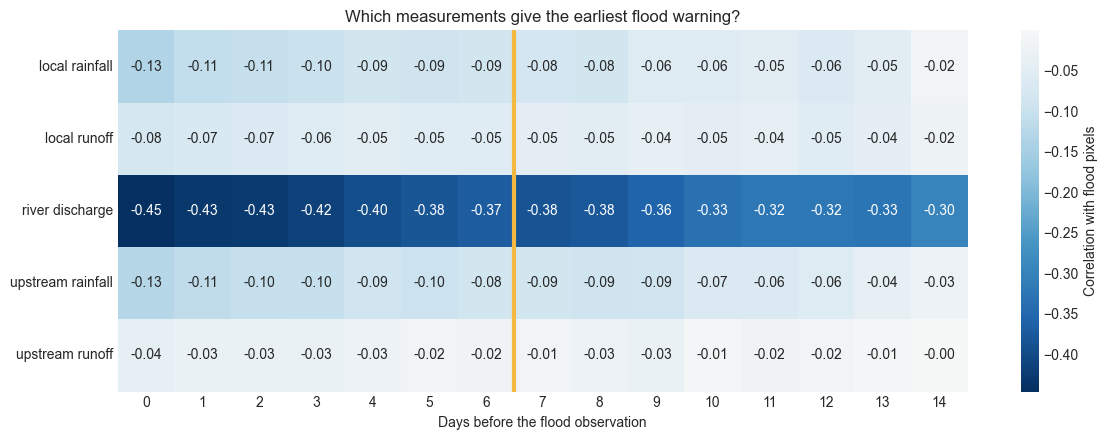

In [3]:
observations = load_aweil_flood_observations(FLOOD_ROOT, counties, years=YEARS)
flood_daily = daily_flood_pixels(observations).groupby('date').agg(
    active_flood_pixels=('active_flood_pixels', 'sum'),
    unusual_flood_pixels=('unusual_flood_pixels', 'sum'),
    mean_cloud_fraction=('mean_cloud_fraction', 'mean'),
)
full_index = pd.date_range(local_daily.index.min(), local_daily.index.max(), freq='D')
flood_daily = flood_daily.reindex(full_index, fill_value=0)
flood_daily.index.name = 'date'

station = load_dartmouth_data()[100205]
discharge = pd.to_numeric(station['Discharge (m3/s)'], errors='coerce')
discharge.index = pd.to_datetime(discharge.index).normalize()

signals = pd.DataFrame({
    'local rainfall': local_daily['precipitation_mm'],
    'local runoff': local_daily['runoff_mm'],
    'upstream rainfall': upstream_daily['precipitation_mm'],
    'upstream runoff': upstream_daily['runoff_mm'],
    'river discharge': discharge,
}).join(flood_daily['active_flood_pixels'].rename('flood_pixels'), how='inner').fillna(0)
lag_results = lag_feature_correlations(
    signals.drop(columns='flood_pixels'), signals['flood_pixels'], lags=range(15)
)
lag_results.to_csv(OUTPUT_TABLES / 'aweil_lag_correlations.csv', index=False)
heatmap = lag_results.pivot(index='signal', columns='lag_days', values='correlation')
fig, axis = plt.subplots(figsize=(12, 4.5))
sns.heatmap(heatmap, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=axis, cbar_kws={'label': 'Correlation with flood pixels'})
axis.axvline(7, color='#f4b942', linewidth=3)
axis.set(xlabel='Days before the flood observation', ylabel='', title='Which measurements give the earliest flood warning?')
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / 'aweil_lag_correlation_heatmap.png', dpi=200)
plt.show()

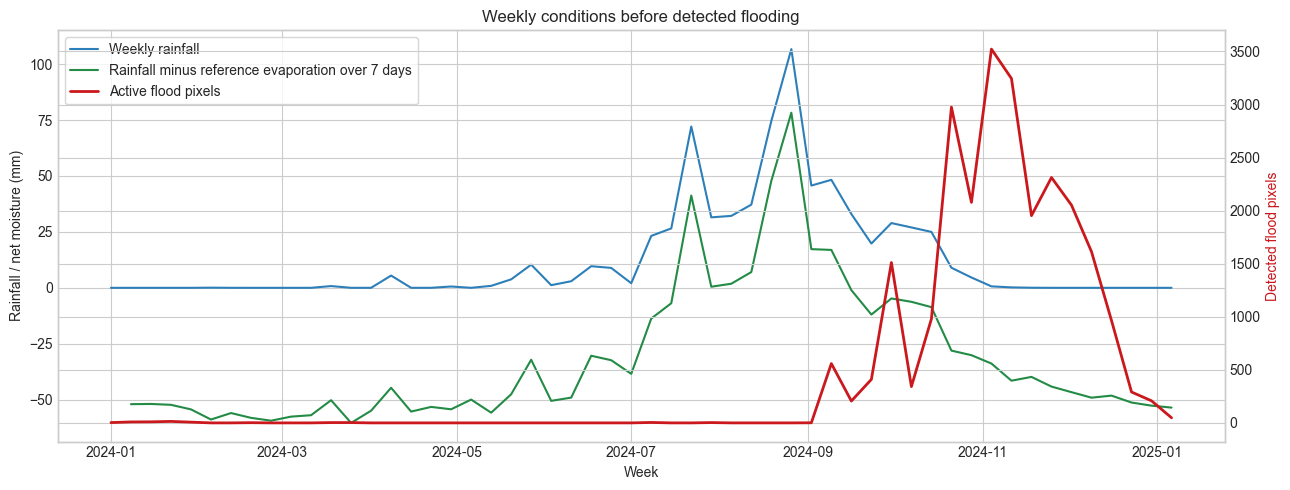

In [4]:
weekly = signals.resample('W-MON').agg({
    'local rainfall': 'sum',
    'local runoff': 'sum',
    'flood_pixels': 'max',
}).dropna()
weekly['seven_day_net_moisture'] = moisture.set_index('date')['net_moisture_7d_mm'].resample('W-MON').last()
weekly.to_csv(OUTPUT_TABLES / 'aweil_weekly_forecast_signals.csv')

fig, axis = plt.subplots(figsize=(13, 5))
axis.plot(weekly.index, weekly['local rainfall'], color='#2c7fb8', label='Weekly rainfall')
axis.plot(weekly.index, weekly['seven_day_net_moisture'], color='#238b45', label='Rainfall minus reference evaporation over 7 days')
axis.set(xlabel='Week', ylabel='Rainfall / net moisture (mm)', title='Weekly conditions before detected flooding')
secondary = axis.twinx()
secondary.plot(weekly.index, weekly['flood_pixels'], color='#cb181d', linewidth=2, label='Active flood pixels')
secondary.set_ylabel('Detected flood pixels', color='#cb181d')
lines, labels = axis.get_legend_handles_labels()
lines2, labels2 = secondary.get_legend_handles_labels()
axis.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / 'aweil_forecast_signals.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Map seasonal agricultural exposure

Flood detections are sampled against the supplied crop and rangeland masks. August represents vegetative growth and flowering; October-November represents maturation and harvest. The maps show detected exposure as a percentage of each county's available crop or rangeland baseline.

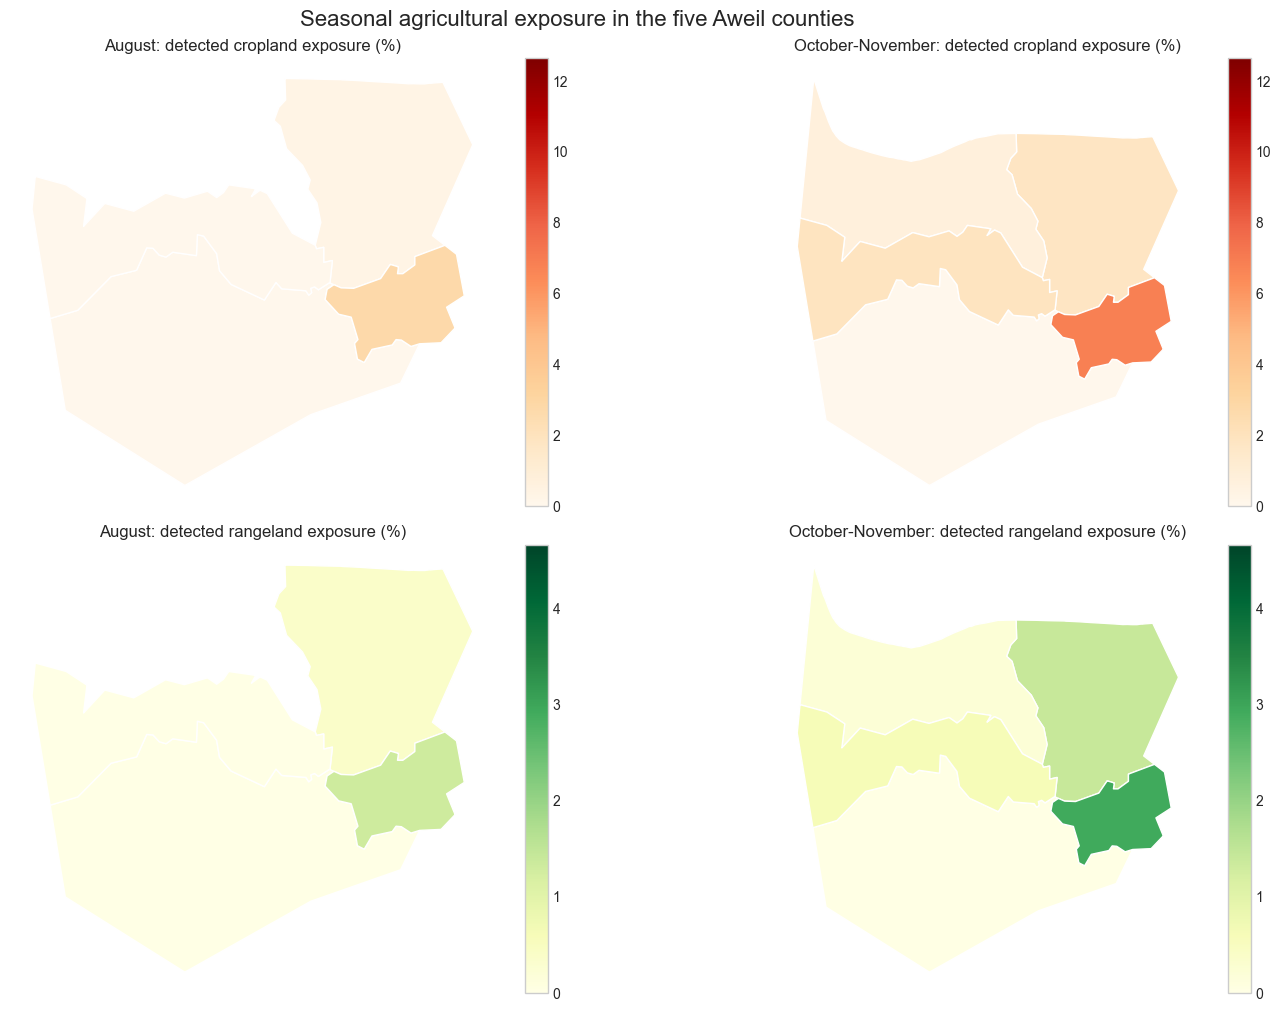

,county,phase,month,flood_type,detected_pixels,crop_exposed_hectares,rangeland_exposed_hectares,crop_hectares,rangeland_hectares,crop_exposed_percent,rangeland_exposed_percent
29,Aweil South,maturation and harvest,10,unusual,367,437.390071,6930.323422,3463.968952,148870.602425,12.626847,4.655267
31,Aweil South,maturation and harvest,11,unusual,309,365.026835,5848.579486,3463.968952,148870.602425,10.537821,3.928633
33,Aweil South,maturation and harvest,12,unusual,295,260.557044,5218.797057,3463.968952,148870.602425,7.521922,3.505593
38,Aweil West,maturation and harvest,10,unusual,286,111.878996,5216.327322,2538.702971,360696.114708,4.406935,1.446183
14,Aweil East,maturation and harvest,10,unusual,507,675.225553,7762.624121,19098.181446,434946.171385,3.535549,1.784732
40,Aweil West,maturation and harvest,11,unusual,195,73.351130,3147.677275,2538.702971,360696.114708,2.889315,0.872667
27,Aweil South,vegetative growth and flowering,9,unusual,144,99.283348,2668.054735,3463.968952,148870.602425,2.866173,1.792197
16,Aweil East,maturation and harvest,11,unusual,445,532.721842,6971.074049,19098.181446,434946.171385,2.789385,1.602744
28,Aweil South,maturation and harvest,10,recurring,182,75.820865,2352.422600,3463.968952,148870.602425,2.188844,1.580179
30,Aweil South,maturation and harvest,11,recurring,173,68.164686,2226.219141,3463.968952,148870.602425,1.967820,1.495405


In [ ]:
baseline = agricultural_baseline(counties, MASK_PATHS)
exposure = seasonal_agricultural_exposure(observations, counties, MASK_PATHS)
exposure = exposure.merge(baseline, on='county', how='left')
exposure['crop_exposed_percent'] = 100 * exposure['crop_exposed_hectares'] / exposure['crop_hectares']
exposure['rangeland_exposed_percent'] = 100 * exposure['rangeland_exposed_hectares'] / exposure['rangeland_hectares']
exposure.to_csv(OUTPUT_TABLES / 'aweil_monthly_agricultural_exposure.csv', index=False)

phase_views = [
    ('Other Months', exposure['month'].isin([1, 2, 3, 4, 5, 6, 7, 8, 12])),
    ('October-November', exposure['month'].isin([10, 11])),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for column, (period_name, period_filter) in enumerate(phase_views):
    period_data = exposure[period_filter].groupby('county', as_index=False).agg(
        crop_exposed_percent=('crop_exposed_percent', 'mean'),
        rangeland_exposed_percent=('rangeland_exposed_percent', 'mean'),
    )
    mapped = counties.merge(period_data, on='county', how='left')
    if period_data.empty:
        message = f'No MODIS flood detections\nin {period_name.lower()} {YEARS[0]}'
        for row, label in enumerate(['cropland', 'rangeland']):
            counties.plot(ax=axes[row, column], facecolor='#e6e6e6', edgecolor='white', linewidth=1)
            axes[row, column].text(0.5, 0.5, message, transform=axes[row, column].transAxes, ha='center', va='center', fontsize=12, weight='bold')
            axes[row, column].set_title(f'{period_name}: detected {label} exposure (%)')
    else:
        crop_max = max(1, float(exposure['crop_exposed_percent'].max()))
        range_max = max(1, float(exposure['rangeland_exposed_percent'].max()))
        mapped.plot(column='crop_exposed_percent', ax=axes[0, column], cmap='OrRd', legend=True, vmin=0, vmax=crop_max, edgecolor='white', linewidth=1)
        mapped.plot(column='rangeland_exposed_percent', ax=axes[1, column], cmap='YlGn', legend=True, vmin=0, vmax=range_max, edgecolor='white', linewidth=1)
        axes[0, column].set_title(f'{period_name}: detected cropland exposure (%)')
        axes[1, column].set_title(f'{period_name}: detected rangeland exposure (%)')
    for axis in axes[:, column]:
        axis.set_axis_off()
fig.suptitle('Seasonal agricultural exposure in the five Aweil counties', fontsize=16)
fig.savefig(OUTPUT_FIGURES / 'aweil_seasonal_agricultural_exposure_maps.png', dpi=200, bbox_inches='tight')
plt.show()
exposure.sort_values('crop_exposed_percent', ascending=False).head(10)

## 4. Data quality and recurring versus unusual floods

The final table reports missing days and cloud values during July-September. It also keeps recurring and unusual detections separate: recurring water may support flood-recession farming, while unusual detections are the more relevant shock signal for crop and livestock planning.

In [6]:
rainy = observations[observations['date'].dt.month.isin([7, 8, 9])]
rainy_days = pd.date_range(f'{YEARS.min()}-07-01', f'{YEARS.max()}-09-30', freq='D')
quality = pd.DataFrame([{
    'period': 'July-September',
    'calendar_days': len(rainy_days),
    'days_with_detected_flood_pixels': rainy['date'].nunique(),
    'days_without_detected_flood_pixels': len(rainy_days.difference(rainy['date'].drop_duplicates())),
    'mean_cloud_fraction_on_flood_records': rainy['cloud_frac'].mean(),
    'unusual_share_of_flood_records': rainy['flood_type'].eq('unusual').mean(),
}])
quality.to_csv(OUTPUT_TABLES / 'aweil_flood_observation_quality.csv', index=False)
quality

,period,calendar_days,days_with_detected_flood_pixels,days_without_detected_flood_pixels,mean_cloud_fraction_on_flood_records,unusual_share_of_flood_records
0,July-September,92,26,66,0.0,0.210135
